In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
outdir = '../data/synth'
outdir = f'{outdir}/SFH_rates_lab_populations'

Quickly check we can pull out which are merging BBH in a self-consistent manner;
here I compare:

- a mask I constructed by poking at the `online` columns
- a mask I constructed on the `history` columns, following hints from one of the provided POSYDON tutorials

In [ ]:
path = f'{outdir}/1e-04_Zsun_population.h5'
df = pd.read_hdf(path, key='oneline')

In [22]:
mask = (df['S1_state_f'] == 'BH') & (df['S2_state_f'] == 'BH') & (df['state_f'] == 'contact')
sum(mask)

181

In [23]:
df = pd.read_hdf(path, key='history')

In [24]:
mask = (df['S1_state'] == 'BH') & (df['S2_state'] == 'BH') & (df['event'] == 'CO_contact')
sum(mask)

181

# Mass and tilt distributions

In [3]:
for i, m in enumerate(['1e-01', '1e-02', '1e-03', '1e-04', '1e+00', '2e-01', '2e+00', '4.5e-01']):
    path = f'{outdir}/{m}_Zsun_population.h5'
    if i == 0:
        df = pd.read_hdf(path, key='oneline')
    else:
        df = pd.concat([
            df, pd.read_hdf(path, key='oneline')
        ])

Note: natal kicks are stored like

[velocity, azimuthal angle, polar angle, phase]

according to https://posydon.org/POSYDON/latest/tutorials-examples/population-synthesis/evolve_single_binaries.html

In [4]:
mask_bbh = (df['S1_state_f'] == 'BH') & (df['S2_state_f'] == 'BH')
mask_merge = mask_bbh & (df['state_f'] == 'contact') 

When we enforce the requirement that it's BBH which merge in a Hubble time,
these distributions become peakier!

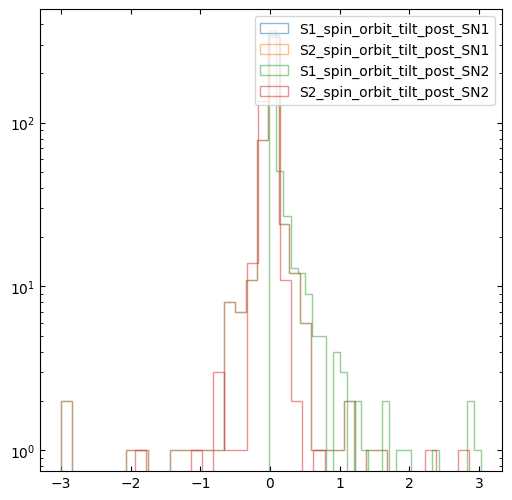

In [5]:
ks = dict(histtype='step', bins=30, alpha=0.5)

fig, ax = plt.subplots(figsize=(6,6))
ax.hist(df['S1_spin_orbit_tilt_first_SN'][mask_merge], label='S1_spin_orbit_tilt_post_SN1', **ks)
ax.hist(df['S2_spin_orbit_tilt_first_SN'][mask_merge], label='S2_spin_orbit_tilt_post_SN1', **ks)
ax.hist(df['S1_spin_orbit_tilt_second_SN'][mask_merge], label='S1_spin_orbit_tilt_post_SN2', **ks)
ax.hist(df['S2_spin_orbit_tilt_second_SN'][mask_merge], label='S2_spin_orbit_tilt_post_SN2', **ks)
ax.set_yscale('log')
ax.legend()
ax.set_box_aspect(1);
ax.tick_params(direction='in', which='both', axis='both', right=True, top=True)

In [6]:
def get_mass_labels(dataset):
    """ indices which label S1 and S2 as primary or secondary depending on final mass """
    m_s1 = dataset['S1_mass_f']
    m_s2 = dataset['S2_mass_f']
    ms = np.column_stack([m_s1, m_s2])
    idxs = np.argsort(ms, axis=1)[:, ::-1]
    return np.take_along_axis(ms, idxs), idxs

In [7]:
ms_sorted, idxs = get_mass_labels(df)

In [8]:
primary_mass = ms_sorted[:, 0]

In [9]:
mass_ratio = ms_sorted[:, 1] / ms_sorted[:, 0]

/var/folders/g2/yjv0x52x4s13srsr95sd8td40000gn/T/ipykernel_28379/4108322566.py:1: RuntimeWarning: invalid value encountered in divide
  mass_ratio = ms_sorted[:, 1] / ms_sorted[:, 0]


In [10]:
total_mass = ms_sorted.sum(axis=-1)

In [11]:
cos_tau = np.column_stack([
    df['S1_spin_orbit_tilt_second_SN'],
    df['S2_spin_orbit_tilt_second_SN']
])

In [12]:
cos_tau_sorted = np.take_along_axis(cos_tau, idxs)

In [25]:
kick_velocities = np.column_stack([
    df['S1_natal_kick_array_0'],
    df['S2_natal_kick_array_0']
])
kick_velocities = np.take_along_axis(kick_velocities, idxs)

Text(0.5, 1.0, 'non-disrupted BBH')

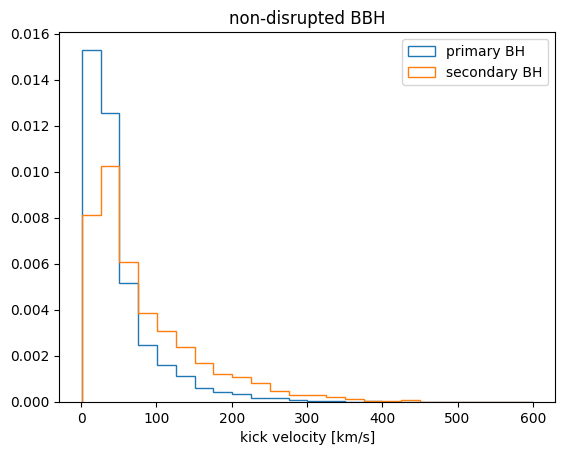

In [68]:
bins = np.linspace(1, 600, 25)

fig, ax = plt.subplots()
ax.hist(kick_velocities[:, 0][mask_bbh], histtype='step', bins=bins, density=True, label='primary BH')
ax.hist(kick_velocities[:, 1][mask_bbh], histtype='step', bins=bins, density=True, label='secondary BH')
ax.legend()
ax.set_xlabel('kick velocity [km/s]')
ax.set_title('non-disrupted BBH')

In [50]:
primary_mass[mask_bbh].min(), primary_mass[mask_bbh].max()

(np.float64(2.5259566642394726), np.float64(60.68341381761696))

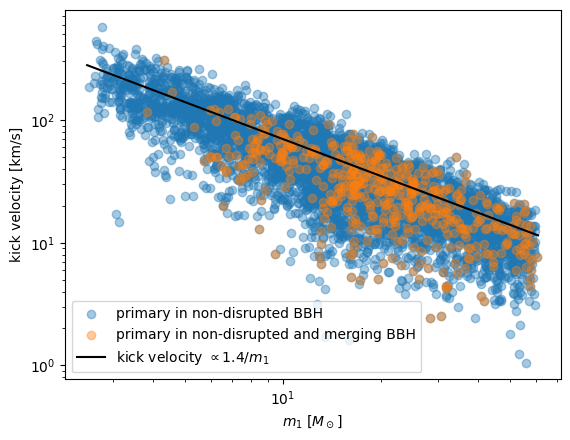

In [70]:
fig, ax = plt.subplots()
ax.scatter(
    primary_mass[mask_bbh],
    kick_velocities[mask_bbh][:, 0],
    alpha=0.4,
    label='primary in non-disrupted BBH'
)
ax.scatter(
    primary_mass[mask_merge],
    kick_velocities[mask_merge][:, 0],
    alpha=0.4,
    label='primary in non-disrupted and merging BBH'
)

xs = np.linspace(2.5, 61)
ax.plot(
    xs,
    1.4 / xs * 500,
    zorder=10,
    color='black',
    label=r'kick velocity $\propto 1.4 / m_1$'
)
ax.loglog()

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'kick velocity [km/s]')

ax.legend();

## primary mass

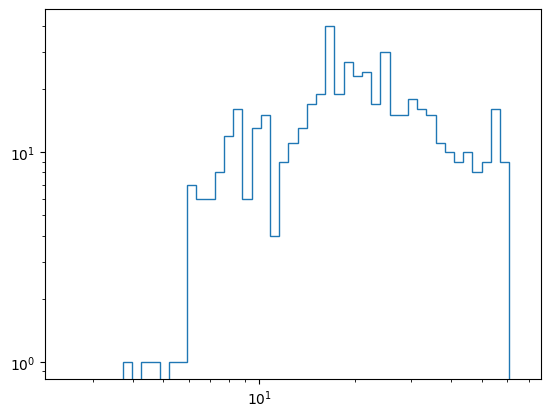

In [13]:
fig, ax = plt.subplots()
ax.hist(primary_mass[mask_merge], histtype='step', bins=np.logspace(np.log10(2.5), np.log10(65), 50));
ax.set_yscale('log')
ax.set_xscale('log')

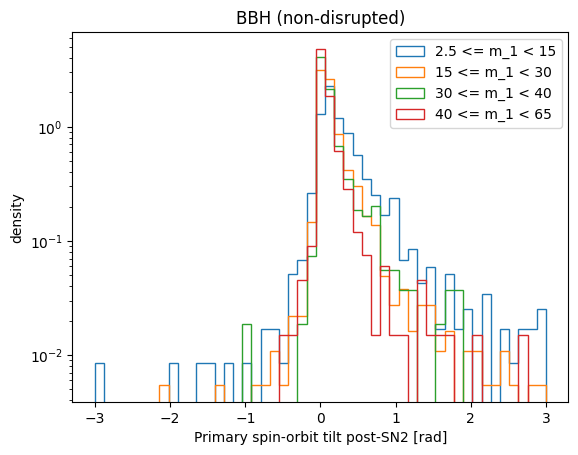

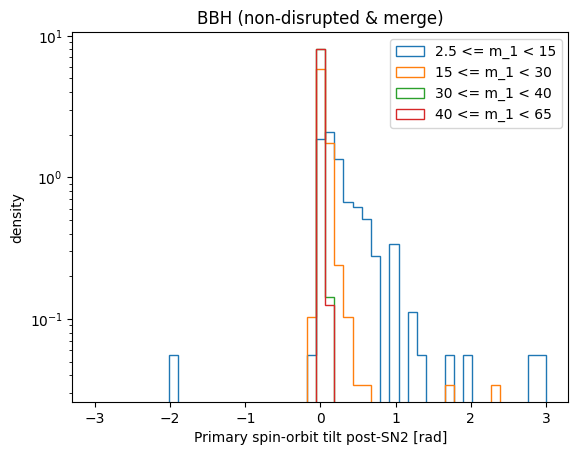

In [159]:
fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [2.5, 15], [15, 30], [30, 40], [40, 65] ]:
    mask = mask_bbh & (primary_mass < b) & (primary_mass >= a)
    ax.hist(cos_tau_sorted[mask][:, 0], label=f'{a} <= m_1 < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted)');
ax.set_xlabel('Primary spin-orbit tilt post-SN2 [rad]')
ax.set_ylabel('density')

fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [2.5, 15], [15, 30], [30, 40], [40, 65] ]:
    mask = mask_merge & (primary_mass < b) & (primary_mass >= a)
    ax.hist(cos_tau_sorted[mask][:, 0], label=f'{a} <= m_1 < {b}', **ks)
ax.set_yscale('log')
ax.legend()
ax.set_title('BBH (non-disrupted & merge)')
ax.set_xlabel('Primary spin-orbit tilt post-SN2 [rad]')
ax.set_ylabel('density');

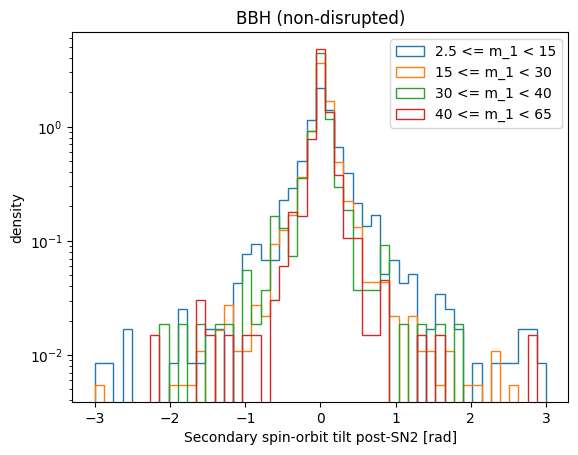

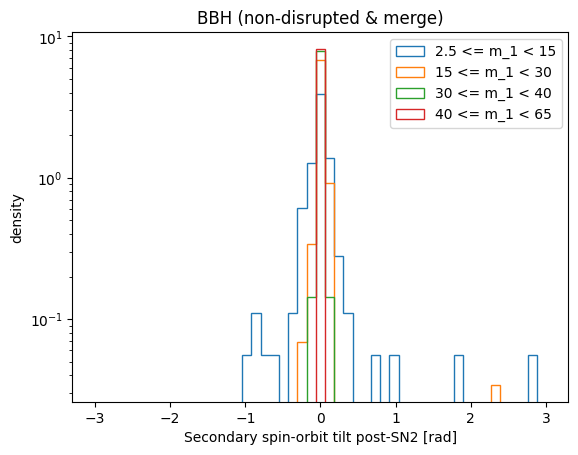

In [170]:
fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [2.5, 15], [15, 30], [30, 40], [40, 65] ]:
    mask = mask_bbh & (primary_mass < b) & (primary_mass >= a)
    ax.hist(cos_tau_sorted[mask][:, 1], label=f'{a} <= m_1 < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted)');
ax.set_xlabel('Secondary spin-orbit tilt post-SN2 [rad]')
ax.set_ylabel('density')
#ax.set_ylim(5e-3, 6)

fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [2.5, 15], [15, 30], [30, 40], [40, 65] ]:
    mask = mask_merge & (primary_mass < b) & (primary_mass >= a)
    ax.hist(cos_tau_sorted[mask][:, 1], label=f'{a} <= m_1 < {b}', **ks)
ax.set_yscale('log')
ax.legend()
ax.set_title('BBH (non-disrupted & merge)')
ax.set_xlabel('Secondary spin-orbit tilt post-SN2 [rad]')
ax.set_ylabel('density');

#ax.set_ylim(5e-3, 6);

## mass ratio

In [147]:
mass_ratio[mask_bbh].min()

np.float64(0.06543791627788974)

Text(0, 0.5, 'density')

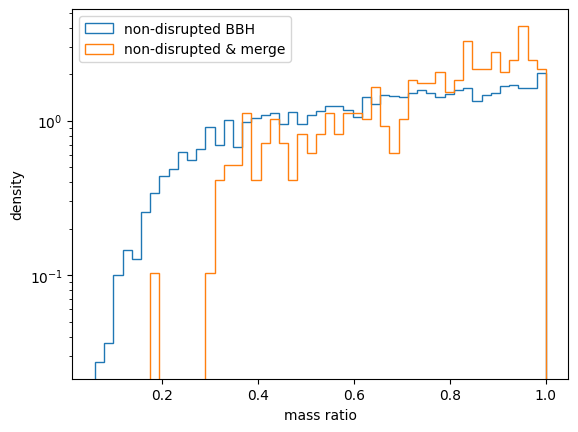

In [163]:
fig, ax = plt.subplots()
bins = np.linspace(0.06, 1, 50)
ax.hist(mass_ratio[mask_bbh], histtype='step', bins=bins, density=True, label='non-disrupted BBH')
ax.hist(mass_ratio[mask_merge], histtype='step', bins=bins, density=True, label='non-disrupted & merge')
ax.set_yscale('log')
ax.legend()
ax.set_xlabel('mass ratio')
ax.set_ylabel('density')

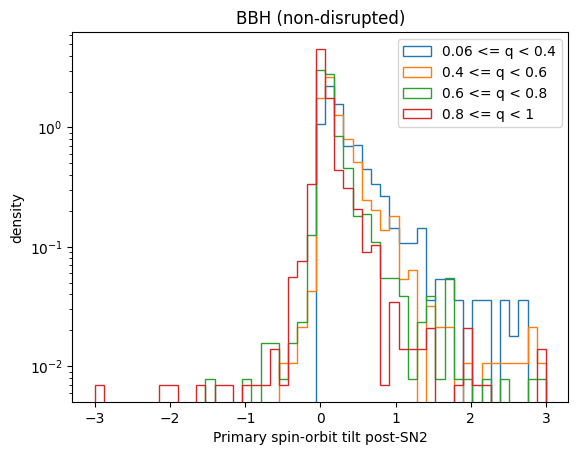

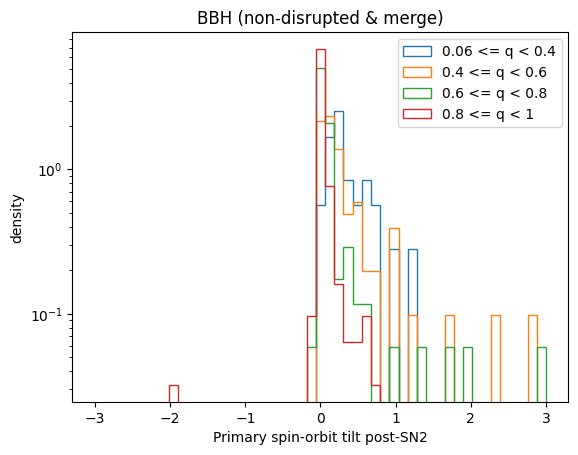

In [166]:
fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [0.06, 0.4], [0.4, 0.6], [0.6, 0.8], [0.8, 1] ]:
    mask = mask_bbh & (mass_ratio < b) & (mass_ratio >= a)
    ax.hist(cos_tau_sorted[mask][:, 0], label=f'{a} <= q < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted)');
ax.set_xlabel('Primary spin-orbit tilt post-SN2')
ax.set_ylabel('density')

fig, ax = plt.subplots()

for (a, b) in [ [0.06, 0.4], [0.4, 0.6], [0.6, 0.8], [0.8, 1] ]:
    mask = mask_merge & (mass_ratio < b) & (mass_ratio >= a)
    ax.hist(cos_tau_sorted[mask][:, 0], label=f'{a} <= q < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted & merge)');
ax.set_xlabel('Primary spin-orbit tilt post-SN2')
ax.set_ylabel('density');

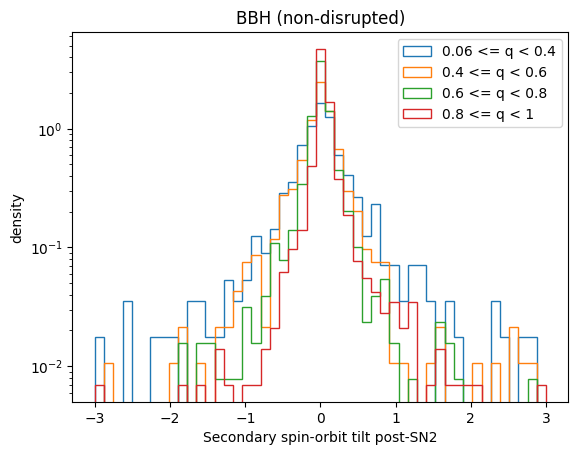

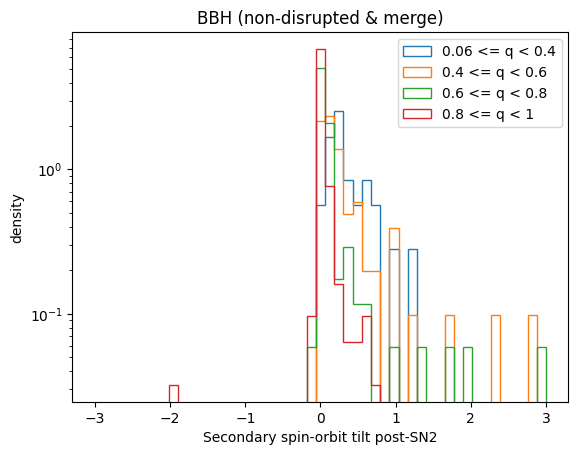

In [167]:
fig, ax = plt.subplots()

ks = dict(histtype='step', bins=np.linspace(-3, 3, 50), density=True)

for (a, b) in [ [0.06, 0.4], [0.4, 0.6], [0.6, 0.8], [0.8, 1] ]:
    mask = mask_bbh & (mass_ratio < b) & (mass_ratio >= a)
    ax.hist(cos_tau_sorted[mask][:, 1], label=f'{a} <= q < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted)');
ax.set_xlabel('Secondary spin-orbit tilt post-SN2')
ax.set_ylabel('density')

fig, ax = plt.subplots()

for (a, b) in [ [0.06, 0.4], [0.4, 0.6], [0.6, 0.8], [0.8, 1] ]:
    mask = mask_merge & (mass_ratio < b) & (mass_ratio >= a)
    ax.hist(cos_tau_sorted[mask][:, 0], label=f'{a} <= q < {b}', **ks)
ax.set_yscale('log')
ax.legend();
ax.set_title('BBH (non-disrupted & merge)');
ax.set_xlabel('Secondary spin-orbit tilt post-SN2')
ax.set_ylabel('density');

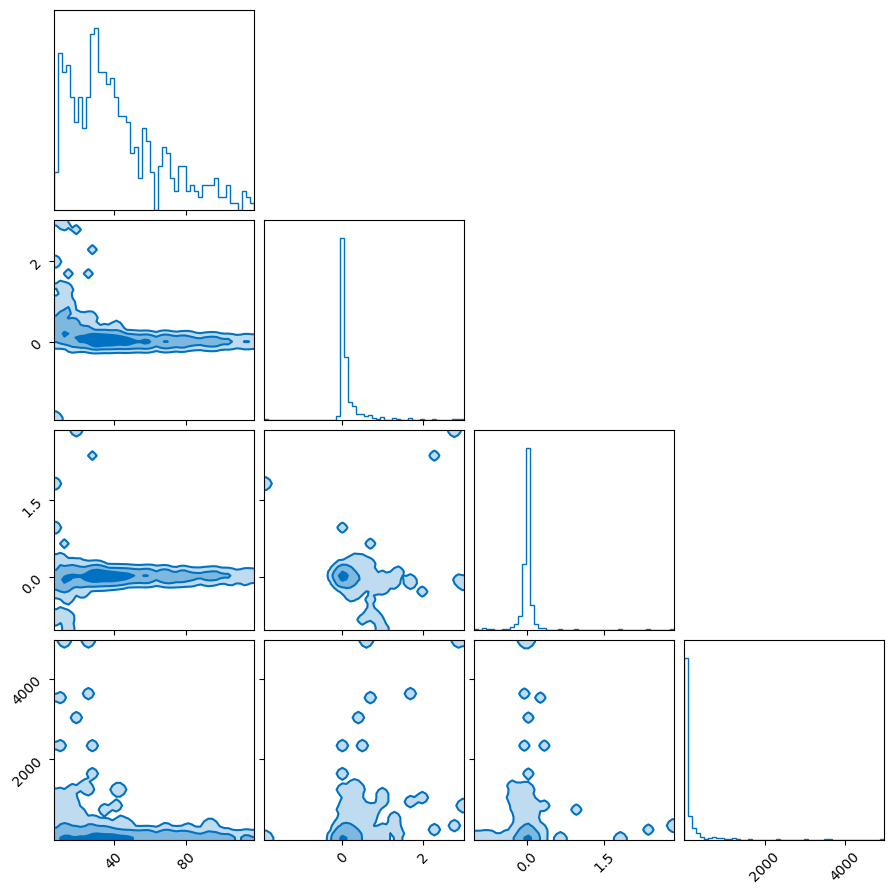

In [182]:
from util import plot_corner

plot_corner(
    np.column_stack([
        total_mass[mask_merge],
        cos_tau_sorted[mask_merge][:, 0],
        cos_tau_sorted[mask_merge][:, 1],
        df['orbital_period_i'][mask_merge]
    ])
);

In [176]:
cos_tau_sorted[mask_bbh].min()

np.float64(nan)

In [31]:
ms = np.column_stack([df['S1_mass_f'], df['S2_mass_f']])

In [41]:
idxs = np.argsort(ms, axis=1)

In [46]:
idxs[:, ::-1]

array([[0, 1],
       [0, 1],
       [1, 0],
       ...,
       [0, 1],
       [0, 1],
       [0, 1]], shape=(10000, 2))

In [42]:
np.take_along_axis(ms, idxs)

array([[0.        , 1.27758353],
       [1.27758353, 1.59628954],
       [0.        , 1.86566246],
       ...,
       [0.        , 8.39377793],
       [1.27758353, 1.60461921],
       [2.90582419, 6.65078325]], shape=(10000, 2))

In [28]:
df['S1_mass_f'][mask_bbh]

binary_index
5       29.040984
19      28.438081
21      55.642112
27       5.330861
39      25.067438
          ...    
9943     4.073339
9971    17.048425
9993    15.810626
9995    14.019567
9999     6.650783
Name: S1_mass_f, Length: 867, dtype: float64

In [ ]:
fig, ax = plt.subplots()
ax.hist()

In [61]:
df['event'].unique()

array(['ZAMS', 'oCE1', 'oMerging1', 'CC1', nan, 'END', 'CC2', 'oCE2',
       'oMerging2', 'oRLO2', 'CO_contact', 'maxtime', 'oDoubleCE2',
       'oDoubleCE1', 'FAILED'], dtype=object)

In [84]:
mask = (df['S1_state'] == 'BH') & (df['S2_state'] == 'BH') & (df['event'] == 'CO_contact')
mbbh = df[mask]

ms1, ms2 = mbbh['S1_mass'], mbbh['S2_mass']
ms = np.column_stack((ms1, ms2))
ms = np.sort(ms, axis=-1)
m2, m1 = ms[:, 0], ms[:, 1]
q = m2 / m1

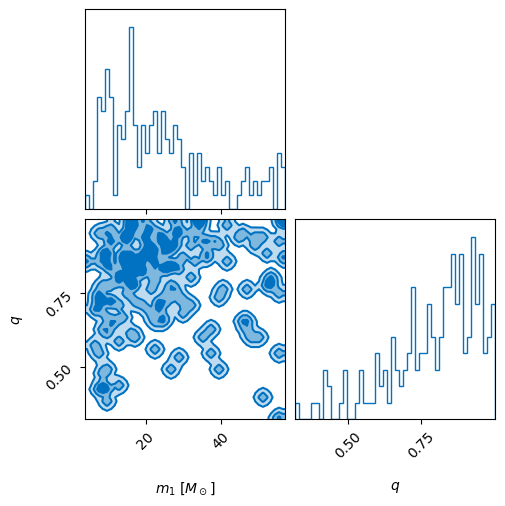

In [ ]:
from util import plot_corner

fig = plot_corner(
    np.column_stack((
        m1, q
    )),
    labels=[r'$m_1$ [$M_\odot$]', r'$q$']
)

In [118]:
import h5ify

import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

parentdir = '/work/submit/newolfe/tilts-and-kicks/data/vt/snr15'
allinj = h5ify.load(f'{parentdir}/ct-iso/all.hdf5')
det = h5ify.load(f'{parentdir}/ct-iso/detectable.hdf5')

In [115]:
from pixelpop.models.gwpop_models import BrokenPowerlawPlusTwoPeaks_PrimaryMass
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

ks = dict(histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), linewidth=3, density=True)

parameters = allinj['parameters']

m1s = jnp.linspace(3, 300, 1_000)
p_m1 = jnp.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass(
    dict(mass_1=m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mmin=parameters['mmin'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(parameters['lam_0'], parameters['lam_1'], parameters['lam_2']),
    mpp_1=parameters['mpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_1=parameters['sigpp_1'],
    sigpp_2=parameters['sigpp_2'],
))

In [122]:
ks = dict(histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), linewidth=3, density=True)

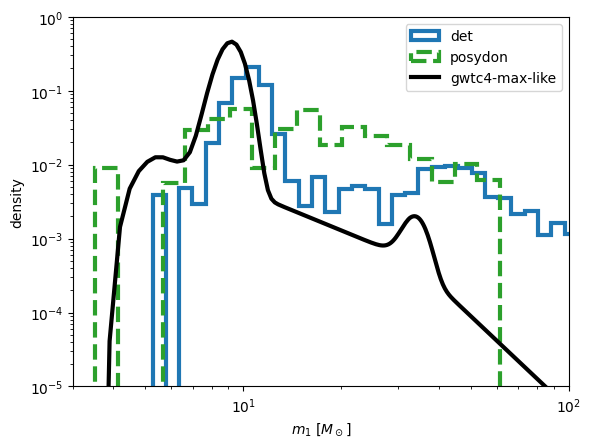

In [125]:
fig, ax = plt.subplots()
ax.hist(det['mass_1'], label='det', **ks)
ax.hist(m1, histtype='step', bins=np.logspace(np.log10(3), np.log10(300), 30), density=True, label='posydon', color='C2', linewidth=3, linestyle='--');
ax.plot(m1s, p_m1, linewidth=3, color='black', label='gwtc4-max-like')
ax.loglog()
ax.set_xlim(3, 100)
ax.set_ylim(1e-5, 1e0)
ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel('density')
ax.legend()
fig.savefig('../notes/figures/25-11-14/m1-posydon-gwtc4.pdf')

In [127]:
ks = dict(histtype='step', bins=jnp.linspace(0.1, 1, 50), linewidth=3, density=True)

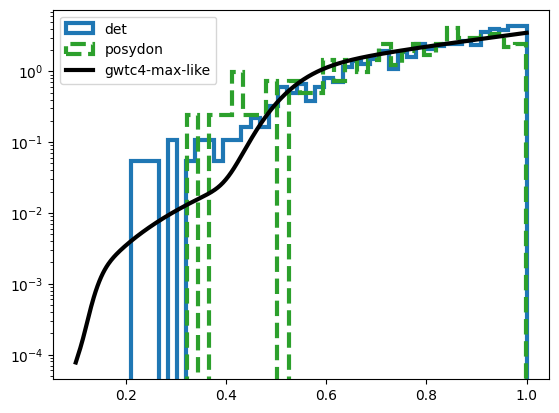

In [ ]:
m1s = jnp.linspace(3, 300, 500)
qs = jnp.linspace(0.1, 1, 500)

mm, qq = jnp.meshgrid(m1s, qs, indexing='ij')

def calc_p_q_marg_m1():
    log_p_q_given_m1 = PowerlawPlusPeak_MassRatio(
        dict(
            mass_1=mm,
            mass_ratio=qq
        ),
        slope=parameters['beta'],
        minimum=parameters['mmin'],
        delta_m=parameters['delta_m_1'] 
    )

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass(
        dict(mass_1=mm),
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mmin=parameters['mmin'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(parameters['lam_0'], parameters['lam_1'], parameters['lam_2']),
        mpp_1=parameters['mpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_1=parameters['sigpp_1'],
        sigpp_2=parameters['sigpp_2'],
    )

    log_p_m1q = log_p_m1 + log_p_q_given_m1
    
    return jnp.trapezoid(
        y=jnp.exp(log_p_m1q),
        x=m1s,
        axis=0
    )

p_q = calc_p_q_marg_m1()

fig, ax = plt.subplots()
ax.hist(det['mass_ratio'], label='det', **ks)
ax.hist(q, histtype='step', bins=30, color='C2', linestyle='--', density=True, label='posydon', linewidth=3);
ax.plot(qs, p_q, linewidth=3, color='black', label='gwtc4-max-like')
ax.set_yscale('log')
ax.legend()
fig.savefig('../notes/figures/25-11-14/q-posydon-gwtc4.pdf')